# Proyek Analisis Sentimen NLP Scrapping Submission

Belajar Pengembangan Machine Learning - Latifah Arum Sulistyaningsih

## Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

#Menggunakan TQDM untuk pemrosesan
%pip install tqdm
from tqdm import tqdm
tqdm.pandas()  # Integrasi tqdm dengan pandas

## Import dataset

In [3]:
df= pd.read_csv("/content/getCont_review.csv")

In [4]:
# Menampilkan dataframe sebagai tabel
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,d542aae1-e92e-483d-8525-8c710f55b14b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,perlu bayar,2,0,8.5.0,2025-05-13 11:22:28,"Hai,\nKami telah menerima umpan balik Anda dan...",2025-05-13 11:33:03,8.5.0
1,e7fa87a8-8bb7-44d7-8ca4-ff9ac77c8da3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"males banget, dulu gratis skrng malah di suruh...",1,0,8.5.0,2025-05-13 10:59:18,"Hai,\nKami telah menerima umpan balik Anda dan...",2025-05-13 11:17:49,8.5.0
2,24afdfb3-c99b-4fa5-91e3-2cc05b747133,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,NaN,2025-05-13 10:34:20,NaN,NaN,NaN
3,259f9a16-392e-4a35-8401-569163a2a4c1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bgus,5,0,8.5.0,2025-05-13 10:22:00,NaN,NaN,8.5.0
4,a4d70455-ca57-48de-8998-ae03f875fe9c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,gak bisa login,1,0,5.8.7,2025-05-13 10:04:12,"Halo, Silahkan lengkapi formulir berikut dan s...",2025-05-13 11:15:37,5.8.7
...,...,...,...,...,...,...,...,...,...,...,...
9995,675c387f-73c3-43aa-9492-b332d7f11891,Aliakbar 88,https://play-lh.googleusercontent.com/a/ACg8oc...,"Get Contac gak kaya dulu,,,,gratis,,,tidak ses...",2,0,5.7.0,2025-01-12 10:33:02,"Halo,\nTerima kasih atas komentar dan masukan ...",2025-01-12 11:19:21,5.7.0
9996,7f7e19a4-5a1c-4a59-b8a9-7c7ae7ad80f6,Masterr Ponsell,https://play-lh.googleusercontent.com/a/ACg8oc...,Joging,4,0,NaN,2025-01-12 10:29:34,NaN,NaN,NaN
9997,bb1ec3eb-c6f4-480c-bb79-42cb7094eedb,Akun Sandi,https://play-lh.googleusercontent.com/a-/ALV-U...,bagus apk nya,5,0,7.4.0,2025-01-12 10:17:21,NaN,NaN,7.4.0
9998,1e24189e-ca63-4aaf-8f5b-24d1c8e2e217,Citra Lestari,https://play-lh.googleusercontent.com/a/ACg8oc...,Ini aplikasi sangat bagus aku pernah dapat kon...,5,0,NaN,2025-01-12 10:14:11,NaN,NaN,NaN


## Informasi Dataset

In [5]:
# Tampilkan ringkasan dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              10000 non-null  object
 1   userName              10000 non-null  object
 2   userImage             10000 non-null  object
 3   content               10000 non-null  object
 4   score                 10000 non-null  int64 
 5   thumbsUpCount         10000 non-null  int64 
 6   reviewCreatedVersion  7075 non-null   object
 7   at                    10000 non-null  object
 8   replyContent          4978 non-null   object
 9   repliedAt             4978 non-null   object
 10  appVersion            7075 non-null   object
dtypes: int64(2), object(9)
memory usage: 859.5+ KB


## Check Missing Value


In [6]:
#Menampilkan jumlah missing value NaN

missing_data = df.isna().sum()
print(missing_data)

reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion    2925
at                         0
replyContent            5022
repliedAt               5022
appVersion              2925
dtype: int64


## Delete column

In [7]:
# Menghapus kolom yg tidak digunakan

df = df.drop(columns=['reviewId', 'userImage', 'thumbsUpCount', 'reviewCreatedVersion', 'replyContent',
                      'repliedAt', 'appVersion'])
print(df.columns)

Index(['userName', 'content', 'score', 'at'], dtype='object')


In [8]:
df

,userName,content,score,at
0,Pengguna Google,perlu bayar,2,2025-05-13 11:22:28
1,Pengguna Google,"males banget, dulu gratis skrng malah di suruh...",1,2025-05-13 10:59:18
2,Pengguna Google,good,5,2025-05-13 10:34:20
3,Pengguna Google,bgus,5,2025-05-13 10:22:00
4,Pengguna Google,gak bisa login,1,2025-05-13 10:04:12
...,...,...,...,...
9995,Aliakbar 88,"Get Contac gak kaya dulu,,,,gratis,,,tidak ses...",2,2025-01-12 10:33:02
9996,Masterr Ponsell,Joging,4,2025-01-12 10:29:34
9997,Akun Sandi,bagus apk nya,5,2025-01-12 10:17:21
9998,Citra Lestari,Ini aplikasi sangat bagus aku pernah dapat kon...,5,2025-01-12 10:14:11


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userName  10000 non-null  object
 1   content   10000 non-null  object
 2   score     10000 non-null  int64 
 3   at        10000 non-null  object
dtypes: int64(1), object(3)
memory usage: 312.6+ KB


## Count Score rating 1 - 5

In [10]:
df['score'].value_counts()

,count
score,
1,5384
5,2997
2,579
3,543
4,497


## Membuat barplot penyebaran score

<Axes: title={'center': 'Persebaran Score pada DataSet'}, xlabel='score'>

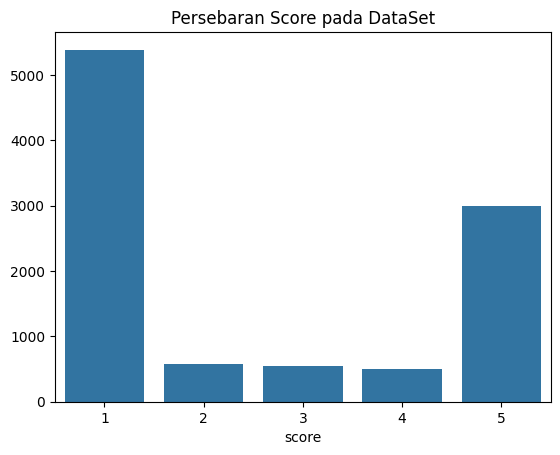

In [11]:
result = df.groupby(['score']).size()
plt.title('Persebaran Score pada DataSet')
sns.color_palette("viridis")
# plot the result
sns.barplot(x = result.index, y = result.values)

## Labelling

In [12]:
# Membuat label pada sentimen
label_num = []

# Iterasi setiap baris dalam DataFrame
for index, row in df.iterrows():
    if row['score'] > 3 :
        label_num.append(1)     # nilai 1 untuk score 4 - 5
    elif row['score'] == 3:
        label_num.append(0)     # nilai 0 untuk score 3
    else:
        label_num.append(-1)    # nilai -1 untuk score 1 - 2

# Tambahkan kolom baru
df['label_num'] = label_num
df

,userName,content,score,at,label_num
0,Pengguna Google,perlu bayar,2,2025-05-13 11:22:28,-1
1,Pengguna Google,"males banget, dulu gratis skrng malah di suruh...",1,2025-05-13 10:59:18,-1
2,Pengguna Google,good,5,2025-05-13 10:34:20,1
3,Pengguna Google,bgus,5,2025-05-13 10:22:00,1
4,Pengguna Google,gak bisa login,1,2025-05-13 10:04:12,-1
...,...,...,...,...,...
9995,Aliakbar 88,"Get Contac gak kaya dulu,,,,gratis,,,tidak ses...",2,2025-01-12 10:33:02,-1
9996,Masterr Ponsell,Joging,4,2025-01-12 10:29:34,1
9997,Akun Sandi,bagus apk nya,5,2025-01-12 10:17:21,1
9998,Citra Lestari,Ini aplikasi sangat bagus aku pernah dapat kon...,5,2025-01-12 10:14:11,1


## Labelling Positive Neutral dan Negative

In [13]:
label = []

# Iterasi setiap baris dalam DataFrame
for index, row in df.iterrows():
    if row['score'] > 3 :
        label.append("positive")     # nilai 1 untuk score 4 - 5
    elif row['score'] == 3:
        label.append("neutral")     # nilai 0 untuk score 3
    else:
        label.append("negative")    # nilai -1 untuk score 1 - 2

# Tambahkan kolom baru
df['label'] = label
df

,userName,content,score,at,label_num,label
0,Pengguna Google,perlu bayar,2,2025-05-13 11:22:28,-1,negative
1,Pengguna Google,"males banget, dulu gratis skrng malah di suruh...",1,2025-05-13 10:59:18,-1,negative
2,Pengguna Google,good,5,2025-05-13 10:34:20,1,positive
3,Pengguna Google,bgus,5,2025-05-13 10:22:00,1,positive
4,Pengguna Google,gak bisa login,1,2025-05-13 10:04:12,-1,negative
...,...,...,...,...,...,...
9995,Aliakbar 88,"Get Contac gak kaya dulu,,,,gratis,,,tidak ses...",2,2025-01-12 10:33:02,-1,negative
9996,Masterr Ponsell,Joging,4,2025-01-12 10:29:34,1,positive
9997,Akun Sandi,bagus apk nya,5,2025-01-12 10:17:21,1,positive
9998,Citra Lestari,Ini aplikasi sangat bagus aku pernah dapat kon...,5,2025-01-12 10:14:11,1,positive


## Distribusi Sentimen pada Label

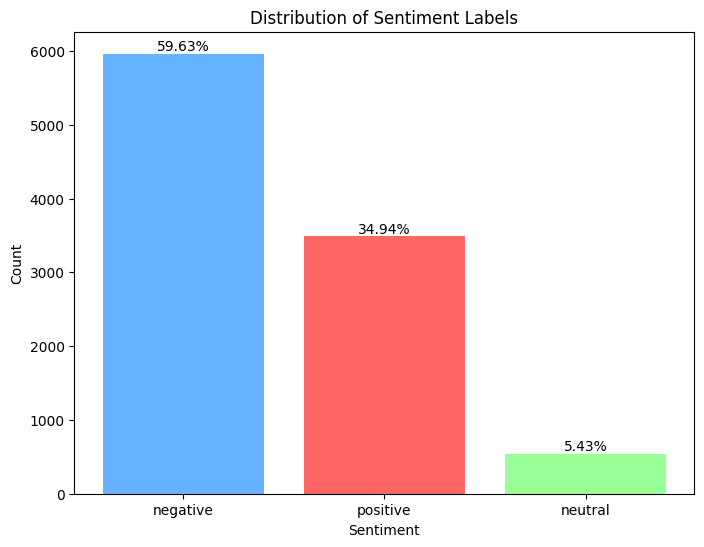

In [14]:
# Hitung jumlah label pada setiap kategori
label_counts = df['label'].value_counts()

# Hitung persentase untuk setiap kategori
label_percentages = label_counts / label_counts.sum() * 100

# Membuat bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(label_counts.index, label_counts.values, color=['#66b3ff', '#ff6666', '#99ff99'])

# Tambahkan persentase di atas setiap bar
for bar, percentage in zip(bars, label_percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{percentage:.2f}%',
        ha='center',
        va='bottom'
    )

plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Distribution of Sentiment Labels')
plt.show()

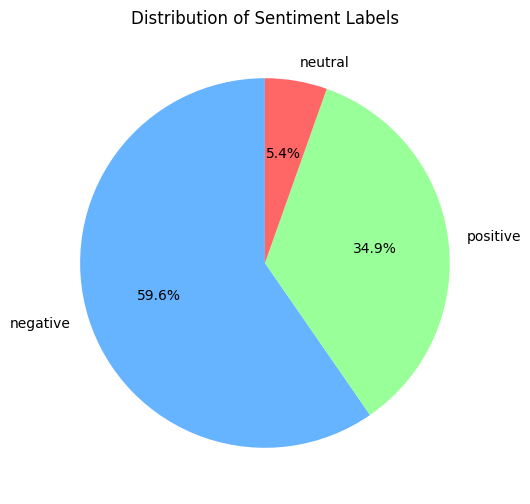

In [15]:
import matplotlib.pyplot as plt

# Hitung jumlah label pada setiap kategori
label_counts = df['label'].value_counts()

# Buat pie chart
plt.figure(figsize=(6, 6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#99ff99', '#ff6666'])
plt.title('Distribution of Sentiment Labels')
plt.show()

## Pre-Processing Data

In [16]:
# Menggunakan Library NLTK

%pip install nltk
import string
import nltk
import re

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [17]:
def preprocess_text(text):
    # Menghapus URL
    text = re.sub(r'https\S+', ' ', text, flags=re.IGNORECASE)

    # Mengubah teks jadi lower case
    text = text.lower()

    # Menghapus mention
    text = re.sub(r'@\S+', ' ', text, flags=re.IGNORECASE)

    # Menghapus hashtag
    text = re.sub(r'#\S+', ' ', text, flags=re.IGNORECASE)

    # Menghapus next karakter
    text = re.sub(r"'\w+", ' ', text)

    # Menghapus tanda baca
    text = re.sub(r'[^\w\s]', ' ', text)

    # Menghapus extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Kolom baru 'content'
df['text_Clean'] = df['content'].progress_apply(preprocess_text)
df

100%|██████████| 10000/10000 [00:00<00:00, 87543.47it/s]


,userName,content,score,at,label_num,label,text_Clean
0,Pengguna Google,perlu bayar,2,2025-05-13 11:22:28,-1,negative,perlu bayar
1,Pengguna Google,"males banget, dulu gratis skrng malah di suruh...",1,2025-05-13 10:59:18,-1,negative,males banget dulu gratis skrng malah di suruh ...
2,Pengguna Google,good,5,2025-05-13 10:34:20,1,positive,good
3,Pengguna Google,bgus,5,2025-05-13 10:22:00,1,positive,bgus
4,Pengguna Google,gak bisa login,1,2025-05-13 10:04:12,-1,negative,gak bisa login
...,...,...,...,...,...,...,...
9995,Aliakbar 88,"Get Contac gak kaya dulu,,,,gratis,,,tidak ses...",2,2025-01-12 10:33:02,-1,negative,get contac gak kaya dulu gratis tidak sesuai h...
9996,Masterr Ponsell,Joging,4,2025-01-12 10:29:34,1,positive,joging
9997,Akun Sandi,bagus apk nya,5,2025-01-12 10:17:21,1,positive,bagus apk nya
9998,Citra Lestari,Ini aplikasi sangat bagus aku pernah dapat kon...,5,2025-01-12 10:14:11,1,positive,ini aplikasi sangat bagus aku pernah dapat kon...


## Mengubah kata slang menjadi baku

In [18]:
# Upload data slang biar nanti dihapus pada saat proses ini
kamus_slang = pd.read_excel('slang.xlsx')

# Menyusun kamus slang sebagai dictionary: slang -> kata baku
slang_dict = dict(zip(kamus_slang['tidak_baku'], kamus_slang['kata_baku']))

# Fungsi untuk mengganti slang dengan kata baku
def ganti_slang(teks):
    return ' '.join([slang_dict.get(kata, kata) for kata in teks.split()])

## Stopwords

In [19]:
# Menerapkan fungsi ganti_slang pada kolom 'text_StopWord'
df['text_Normalization'] = df['text_Clean'].progress_apply(ganti_slang)
df

100%|██████████| 10000/10000 [00:00<00:00, 353317.61it/s]


,userName,content,score,at,label_num,label,text_Clean,text_Normalization
0,Pengguna Google,perlu bayar,2,2025-05-13 11:22:28,-1,negative,perlu bayar,perlu bayar
1,Pengguna Google,"males banget, dulu gratis skrng malah di suruh...",1,2025-05-13 10:59:18,-1,negative,males banget dulu gratis skrng malah di suruh ...,malas banget dulu gratis sekarang malah di sur...
2,Pengguna Google,good,5,2025-05-13 10:34:20,1,positive,good,good
3,Pengguna Google,bgus,5,2025-05-13 10:22:00,1,positive,bgus,bagus
4,Pengguna Google,gak bisa login,1,2025-05-13 10:04:12,-1,negative,gak bisa login,tidak bisa login
...,...,...,...,...,...,...,...,...
9995,Aliakbar 88,"Get Contac gak kaya dulu,,,,gratis,,,tidak ses...",2,2025-01-12 10:33:02,-1,negative,get contac gak kaya dulu gratis tidak sesuai h...,get contac tidak kayak dulu gratis tidak sesua...
9996,Masterr Ponsell,Joging,4,2025-01-12 10:29:34,1,positive,joging,joging
9997,Akun Sandi,bagus apk nya,5,2025-01-12 10:17:21,1,positive,bagus apk nya,bagus apk ya
9998,Citra Lestari,Ini aplikasi sangat bagus aku pernah dapat kon...,5,2025-01-12 10:14:11,1,positive,ini aplikasi sangat bagus aku pernah dapat kon...,ini aplikasi sangat bagus aku pernah dapat kon...


In [20]:
import nltk.corpus
nltk.download('stopwords') # download stopwords
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
# Hapus kata umum

stop = stopwords.words('indonesian')
df['text_StopWord'] = df['text_Normalization'].progress_apply(lambda x:' '.join([word for word in x.split() if word not in (stop)]))
df

100%|██████████| 10000/10000 [00:00<00:00, 14390.39it/s]


,userName,content,score,at,label_num,label,text_Clean,text_Normalization,text_StopWord
0,Pengguna Google,perlu bayar,2,2025-05-13 11:22:28,-1,negative,perlu bayar,perlu bayar,bayar
1,Pengguna Google,"males banget, dulu gratis skrng malah di suruh...",1,2025-05-13 10:59:18,-1,negative,males banget dulu gratis skrng malah di suruh ...,malas banget dulu gratis sekarang malah di sur...,malas banget gratis suruh beli premium
2,Pengguna Google,good,5,2025-05-13 10:34:20,1,positive,good,good,good
3,Pengguna Google,bgus,5,2025-05-13 10:22:00,1,positive,bgus,bagus,bagus
4,Pengguna Google,gak bisa login,1,2025-05-13 10:04:12,-1,negative,gak bisa login,tidak bisa login,login
...,...,...,...,...,...,...,...,...,...
9995,Aliakbar 88,"Get Contac gak kaya dulu,,,,gratis,,,tidak ses...",2,2025-01-12 10:33:02,-1,negative,get contac gak kaya dulu gratis tidak sesuai h...,get contac tidak kayak dulu gratis tidak sesua...,get contac kayak gratis sesuai harapan
9996,Masterr Ponsell,Joging,4,2025-01-12 10:29:34,1,positive,joging,joging,joging
9997,Akun Sandi,bagus apk nya,5,2025-01-12 10:17:21,1,positive,bagus apk nya,bagus apk ya,bagus apk ya
9998,Citra Lestari,Ini aplikasi sangat bagus aku pernah dapat kon...,5,2025-01-12 10:14:11,1,positive,ini aplikasi sangat bagus aku pernah dapat kon...,ini aplikasi sangat bagus aku pernah dapat kon...,aplikasi bagus kontak dikenali lihat getcontac...


## Tokenizing

In [22]:
# import word_tokenize
from nltk.tokenize import sent_tokenize, word_tokenize

# Tokenize menggunakan Regexp
from nltk.tokenize import RegexpTokenizer

In [23]:
regexp = RegexpTokenizer('\w+')
df['text_Tokenization']=df['text_StopWord'].progress_apply(regexp.tokenize)
df

100%|██████████| 10000/10000 [00:00<00:00, 331120.55it/s]


,userName,content,score,at,label_num,label,text_Clean,text_Normalization,text_StopWord,text_Tokenization
0,Pengguna Google,perlu bayar,2,2025-05-13 11:22:28,-1,negative,perlu bayar,perlu bayar,bayar,[bayar]
1,Pengguna Google,"males banget, dulu gratis skrng malah di suruh...",1,2025-05-13 10:59:18,-1,negative,males banget dulu gratis skrng malah di suruh ...,malas banget dulu gratis sekarang malah di sur...,malas banget gratis suruh beli premium,"[malas, banget, gratis, suruh, beli, premium]"
2,Pengguna Google,good,5,2025-05-13 10:34:20,1,positive,good,good,good,[good]
3,Pengguna Google,bgus,5,2025-05-13 10:22:00,1,positive,bgus,bagus,bagus,[bagus]
4,Pengguna Google,gak bisa login,1,2025-05-13 10:04:12,-1,negative,gak bisa login,tidak bisa login,login,[login]
...,...,...,...,...,...,...,...,...,...,...
9995,Aliakbar 88,"Get Contac gak kaya dulu,,,,gratis,,,tidak ses...",2,2025-01-12 10:33:02,-1,negative,get contac gak kaya dulu gratis tidak sesuai h...,get contac tidak kayak dulu gratis tidak sesua...,get contac kayak gratis sesuai harapan,"[get, contac, kayak, gratis, sesuai, harapan]"
9996,Masterr Ponsell,Joging,4,2025-01-12 10:29:34,1,positive,joging,joging,joging,[joging]
9997,Akun Sandi,bagus apk nya,5,2025-01-12 10:17:21,1,positive,bagus apk nya,bagus apk ya,bagus apk ya,"[bagus, apk, ya]"
9998,Citra Lestari,Ini aplikasi sangat bagus aku pernah dapat kon...,5,2025-01-12 10:14:11,1,positive,ini aplikasi sangat bagus aku pernah dapat kon...,ini aplikasi sangat bagus aku pernah dapat kon...,aplikasi bagus kontak dikenali lihat getcontac...,"[aplikasi, bagus, kontak, dikenali, lihat, get..."


## Stemming

In [24]:
# Sastrawi package
%pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 12.1 MB/s eta 0:00:00


In [25]:
# Stemming
factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [26]:
# Melakukan stemming dari hasil tokens
df['text_Stemmindo'] = df['text_Tokenization'].progress_apply(lambda x: [stemmer.stem(y) for y in x])

# check dataframe
df

100%|██████████| 10000/10000 [06:57<00:00, 23.95it/s]


,userName,content,score,at,label_num,label,text_Clean,text_Normalization,text_StopWord,text_Tokenization,text_Stemmindo
0,Pengguna Google,perlu bayar,2,2025-05-13 11:22:28,-1,negative,perlu bayar,perlu bayar,bayar,[bayar],[bayar]
1,Pengguna Google,"males banget, dulu gratis skrng malah di suruh...",1,2025-05-13 10:59:18,-1,negative,males banget dulu gratis skrng malah di suruh ...,malas banget dulu gratis sekarang malah di sur...,malas banget gratis suruh beli premium,"[malas, banget, gratis, suruh, beli, premium]","[malas, banget, gratis, suruh, beli, premium]"
2,Pengguna Google,good,5,2025-05-13 10:34:20,1,positive,good,good,good,[good],[good]
3,Pengguna Google,bgus,5,2025-05-13 10:22:00,1,positive,bgus,bagus,bagus,[bagus],[bagus]
4,Pengguna Google,gak bisa login,1,2025-05-13 10:04:12,-1,negative,gak bisa login,tidak bisa login,login,[login],[login]
...,...,...,...,...,...,...,...,...,...,...,...
9995,Aliakbar 88,"Get Contac gak kaya dulu,,,,gratis,,,tidak ses...",2,2025-01-12 10:33:02,-1,negative,get contac gak kaya dulu gratis tidak sesuai h...,get contac tidak kayak dulu gratis tidak sesua...,get contac kayak gratis sesuai harapan,"[get, contac, kayak, gratis, sesuai, harapan]","[get, contac, kayak, gratis, sesuai, harap]"
9996,Masterr Ponsell,Joging,4,2025-01-12 10:29:34,1,positive,joging,joging,joging,[joging],[joging]
9997,Akun Sandi,bagus apk nya,5,2025-01-12 10:17:21,1,positive,bagus apk nya,bagus apk ya,bagus apk ya,"[bagus, apk, ya]","[bagus, apk, ya]"
9998,Citra Lestari,Ini aplikasi sangat bagus aku pernah dapat kon...,5,2025-01-12 10:14:11,1,positive,ini aplikasi sangat bagus aku pernah dapat kon...,ini aplikasi sangat bagus aku pernah dapat kon...,aplikasi bagus kontak dikenali lihat getcontac...,"[aplikasi, bagus, kontak, dikenali, lihat, get...","[aplikasi, bagus, kontak, nali, lihat, getcont..."


In [27]:
# Melakukan string stemming
df['text_String'] = df['text_Stemmindo'].progress_apply(lambda x: ' '.join([item for item in x if len(item)>3]))
df

100%|██████████| 10000/10000 [00:00<00:00, 437919.36it/s]


,userName,content,score,at,label_num,label,text_Clean,text_Normalization,text_StopWord,text_Tokenization,text_Stemmindo,text_String
0,Pengguna Google,perlu bayar,2,2025-05-13 11:22:28,-1,negative,perlu bayar,perlu bayar,bayar,[bayar],[bayar],bayar
1,Pengguna Google,"males banget, dulu gratis skrng malah di suruh...",1,2025-05-13 10:59:18,-1,negative,males banget dulu gratis skrng malah di suruh ...,malas banget dulu gratis sekarang malah di sur...,malas banget gratis suruh beli premium,"[malas, banget, gratis, suruh, beli, premium]","[malas, banget, gratis, suruh, beli, premium]",malas banget gratis suruh beli premium
2,Pengguna Google,good,5,2025-05-13 10:34:20,1,positive,good,good,good,[good],[good],good
3,Pengguna Google,bgus,5,2025-05-13 10:22:00,1,positive,bgus,bagus,bagus,[bagus],[bagus],bagus
4,Pengguna Google,gak bisa login,1,2025-05-13 10:04:12,-1,negative,gak bisa login,tidak bisa login,login,[login],[login],login
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Aliakbar 88,"Get Contac gak kaya dulu,,,,gratis,,,tidak ses...",2,2025-01-12 10:33:02,-1,negative,get contac gak kaya dulu gratis tidak sesuai h...,get contac tidak kayak dulu gratis tidak sesua...,get contac kayak gratis sesuai harapan,"[get, contac, kayak, gratis, sesuai, harapan]","[get, contac, kayak, gratis, sesuai, harap]",contac kayak gratis sesuai harap
9996,Masterr Ponsell,Joging,4,2025-01-12 10:29:34,1,positive,joging,joging,joging,[joging],[joging],joging
9997,Akun Sandi,bagus apk nya,5,2025-01-12 10:17:21,1,positive,bagus apk nya,bagus apk ya,bagus apk ya,"[bagus, apk, ya]","[bagus, apk, ya]",bagus
9998,Citra Lestari,Ini aplikasi sangat bagus aku pernah dapat kon...,5,2025-01-12 10:14:11,1,positive,ini aplikasi sangat bagus aku pernah dapat kon...,ini aplikasi sangat bagus aku pernah dapat kon...,aplikasi bagus kontak dikenali lihat getcontac...,"[aplikasi, bagus, kontak, dikenali, lihat, get...","[aplikasi, bagus, kontak, nali, lihat, getcont...",aplikasi bagus kontak nali lihat getcontact teman


In [28]:
# Cek lagi info dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   userName            10000 non-null  object
 1   content             10000 non-null  object
 2   score               10000 non-null  int64 
 3   at                  10000 non-null  object
 4   label_num           10000 non-null  int64 
 5   label               10000 non-null  object
 6   text_Clean          10000 non-null  object
 7   text_Normalization  10000 non-null  object
 8   text_StopWord       10000 non-null  object
 9   text_Tokenization   10000 non-null  object
 10  text_Stemmindo      10000 non-null  object
 11  text_String         10000 non-null  object
dtypes: int64(2), object(10)
memory usage: 937.6+ KB


## Save hasil Pre-Processing

In [29]:
# Simpan hasil preprosesing ke csv
df.to_csv('prepro_getcontact.csv',index= False)

## Visualisasi Word Cloud

In [30]:
%pip install wordcloud
import cv2
from wordcloud import WordCloud

In [31]:
# Download gambar masking
!wget https://raw.githubusercontent.com/ksnugroho/klasifikasi-spam-sms/master/img/cloud.jpg

--2025-05-15 06:55:47--  https://raw.githubusercontent.com/ksnugroho/klasifikasi-spam-sms/master/img/cloud.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 34396 (34K) [image/jpeg]
Saving to: ‘cloud.jpg’

cloud.jpg           100%[===================>]  33.59K  --.-KB/s    in 0.002s  

2025-05-15 06:55:47 (15.4 MB/s) - ‘cloud.jpg’ saved [34396/34396]



In [32]:
originalImage = cv2.imread('cloud.jpg')
grayImage = cv2.cvtColor(originalImage, cv2.COLOR_BGR2GRAY)
(thresh, cloud_mask) = cv2.threshold(grayImage, 100, 255, cv2.THRESH_BINARY)

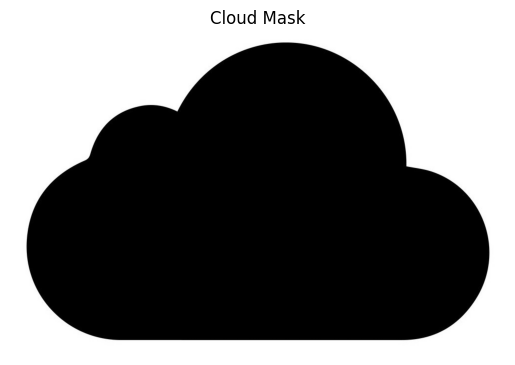

In [33]:
import cv2
import matplotlib.pyplot as plt

# Read the image in grayscale
cloud_mask = cv2.imread('cloud.jpg', cv2.IMREAD_GRAYSCALE)

# Check if the image was loaded correctly
if cloud_mask is None:
    print("Error: Image not loaded correctly.")
else:
    # Display the mask using matplotlib
    plt.imshow(cloud_mask, cmap='gray')
    plt.title('Cloud Mask')
    plt.axis('off')  # Optional, to hide the axes
    plt.show()

 WordCloud for Positive Sentiment

In [34]:
df_p=df[df['label_num']==1]

all_words_lem = ' '.join([word for word in df_p['text_String']])

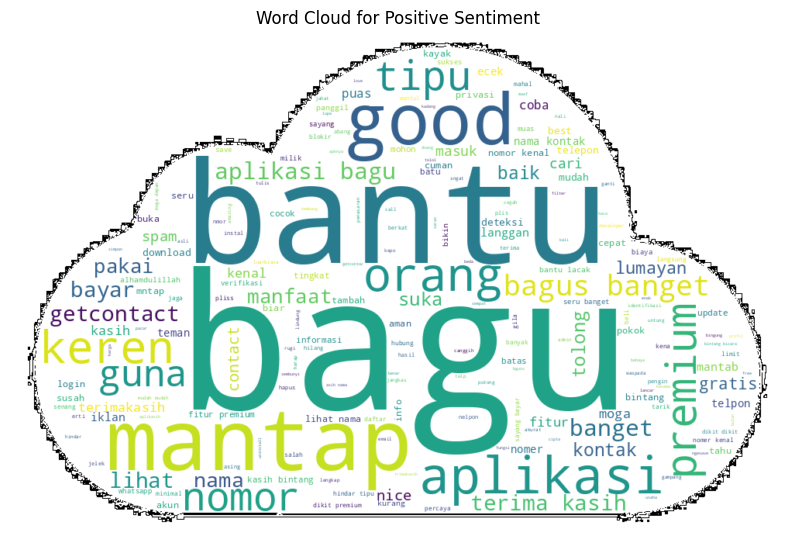

In [35]:
# Buat dan tampilkan word cloud
wordcloud = WordCloud(mask=cloud_mask, background_color='white', contour_width=1, contour_color='black').generate(all_words_lem)

# Tampilkan word cloud menggunakan matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Positive Sentiment')
plt.axis('off') # Opsional, untuk menyembunyikan sumbu
plt.show()

WordCloud for Neutral Sentiment

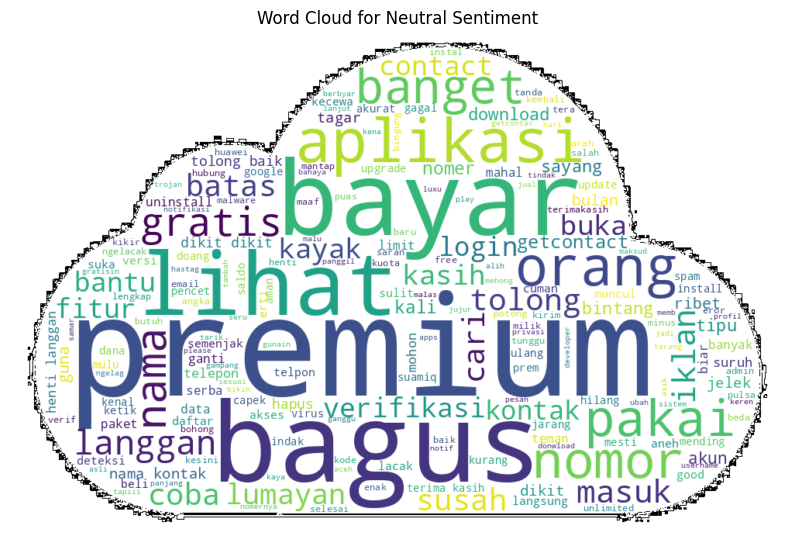

In [36]:
# Filter data frame untuk sentiment netral
df_n = df[df['label_num'] == 0]

# Gabungkan semua kata dalam kolom 'text_string' yang memiliki sentimen netral
all_words_lem = ' '.join([word for word in df_n['text_String']])

# Buat dan tampilkan word cloud
wordcloud = WordCloud(mask=cloud_mask, background_color='white', contour_width=1, contour_color='black').generate(all_words_lem)

# Tampilkan word cloud menggunakan matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Neutral Sentiment')
plt.axis('off') # Opsional, untuk menyembunyikan sumbu
plt.show()

WordCloud for Negative Sentiment

In [37]:
# Filter data frame untuk sentiment negatif
df_n = df[df['label_num'] == -1]

# Gabungkan semua kata dalam kolom 'text_string' yang memiliki sentimen negatif
all_words_lem = ' '.join([word for word in df_n['text_String']])

# Filter data frame untuk sentiment negatif
df_n = df[df['label_num'] == -1]

# Gabungkan semua kata dalam kolom 'text_string' yang memiliki sentimen negatif
all_words_lem = ' '.join([word for word in df_n['text_String']])

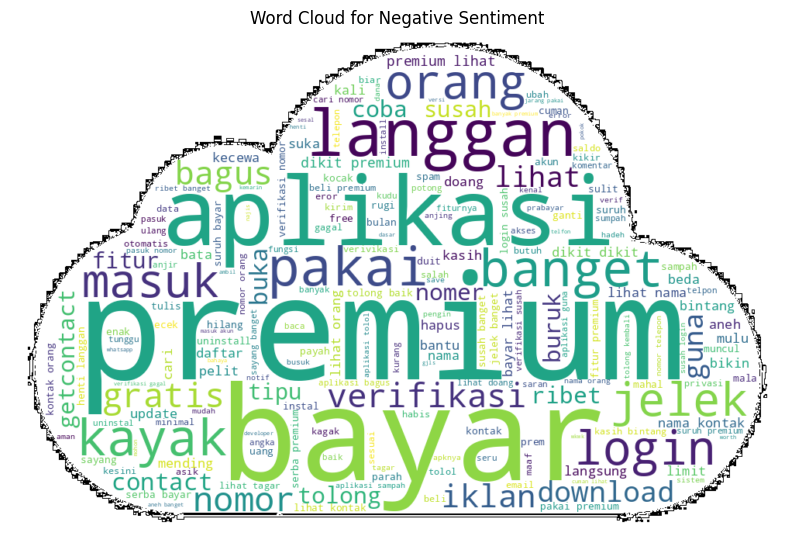

In [38]:
# Buat dan tampilkan word cloud
wordcloud = WordCloud(mask=cloud_mask, background_color='white', contour_width=1, contour_color='black').generate(all_words_lem)

# Tampilkan word cloud menggunakan matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud for Negative Sentiment')
plt.axis('off') # Opsional, untuk menyembunyikan sumbu
plt.show()

## Kata yang sering muncul pada review

In [39]:
nltk.download('punkt')
nltk.download('punkt_tab') # Download the required punkt_tab resource

from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

words = nltk.word_tokenize(all_words_lem)
fd = FreqDist(words)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [40]:
fd.most_common(3)

[('premium', 1896), ('bayar', 1393), ('aplikasi', 1008)]

In [41]:
fd.tabulate(3)

 premium    bayar aplikasi 
    1896     1393     1008 


In [42]:
# Obtain top 10 words
top_10 = fd.most_common(10)

# Create pandas series to make plotting easier
fdist = pd.Series(dict(top_10))

<ipython-input-43-b0a7e8bd1792>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=fdist.index, x=fdist.values, palette='viridis')


<Axes: title={'center': '10 kata paling sering muncul pada review'}, ylabel='None'>

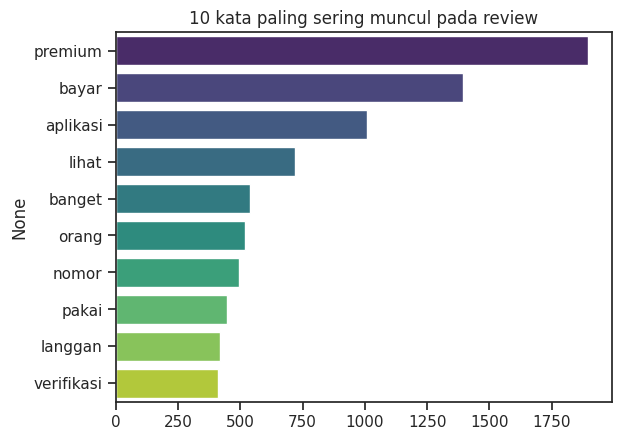

In [43]:
sns.set_theme(style="ticks")

# title
plt.title('10 kata paling sering muncul pada review')

# Create barplot
sns.barplot(y=fdist.index, x=fdist.values, palette='viridis')

## Modelling

In [44]:
df = pd.read_csv('prepro_getcontact.csv')

In [45]:
df

,userName,content,score,at,label_num,label,text_Clean,text_Normalization,text_StopWord,text_Tokenization,text_Stemmindo,text_String
0,Pengguna Google,perlu bayar,2,2025-05-13 11:22:28,-1,negative,perlu bayar,perlu bayar,bayar,['bayar'],['bayar'],bayar
1,Pengguna Google,"males banget, dulu gratis skrng malah di suruh...",1,2025-05-13 10:59:18,-1,negative,males banget dulu gratis skrng malah di suruh ...,malas banget dulu gratis sekarang malah di sur...,malas banget gratis suruh beli premium,"['malas', 'banget', 'gratis', 'suruh', 'beli',...","['malas', 'banget', 'gratis', 'suruh', 'beli',...",malas banget gratis suruh beli premium
2,Pengguna Google,good,5,2025-05-13 10:34:20,1,positive,good,good,good,['good'],['good'],good
3,Pengguna Google,bgus,5,2025-05-13 10:22:00,1,positive,bgus,bagus,bagus,['bagus'],['bagus'],bagus
4,Pengguna Google,gak bisa login,1,2025-05-13 10:04:12,-1,negative,gak bisa login,tidak bisa login,login,['login'],['login'],login
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Aliakbar 88,"Get Contac gak kaya dulu,,,,gratis,,,tidak ses...",2,2025-01-12 10:33:02,-1,negative,get contac gak kaya dulu gratis tidak sesuai h...,get contac tidak kayak dulu gratis tidak sesua...,get contac kayak gratis sesuai harapan,"['get', 'contac', 'kayak', 'gratis', 'sesuai',...","['get', 'contac', 'kayak', 'gratis', 'sesuai',...",contac kayak gratis sesuai harap
9996,Masterr Ponsell,Joging,4,2025-01-12 10:29:34,1,positive,joging,joging,joging,['joging'],['joging'],joging
9997,Akun Sandi,bagus apk nya,5,2025-01-12 10:17:21,1,positive,bagus apk nya,bagus apk ya,bagus apk ya,"['bagus', 'apk', 'ya']","['bagus', 'apk', 'ya']",bagus
9998,Citra Lestari,Ini aplikasi sangat bagus aku pernah dapat kon...,5,2025-01-12 10:14:11,1,positive,ini aplikasi sangat bagus aku pernah dapat kon...,ini aplikasi sangat bagus aku pernah dapat kon...,aplikasi bagus kontak dikenali lihat getcontac...,"['aplikasi', 'bagus', 'kontak', 'dikenali', 'l...","['aplikasi', 'bagus', 'kontak', 'nali', 'lihat...",aplikasi bagus kontak nali lihat getcontact teman


In [46]:
# Tampilkan Text String
df['text_String']

,text_String
0,bayar
1,malas banget gratis suruh beli premium
2,good
3,bagus
4,login
...,...
9995,contac kayak gratis sesuai harap
9996,joging
9997,bagus
9998,aplikasi bagus kontak nali lihat getcontact teman


In [47]:
# Text Preprocessing & Cleaning
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from wordcloud import WordCloud,STOPWORDS
from nltk import SnowballStemmer
from tqdm import tqdm
import re

# Split Data
from sklearn.model_selection import train_test_split
# Imbalanced handle
from imblearn.over_sampling import SMOTE

# Modelling
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score

# Data Visualization
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

## Split X & Y

In [48]:
X = df['text_String']
y = df['label_num']

In [49]:
X

,text_String
0,bayar
1,malas banget gratis suruh beli premium
2,good
3,bagus
4,login
...,...
9995,contac kayak gratis sesuai harap
9996,joging
9997,bagus
9998,aplikasi bagus kontak nali lihat getcontact teman


In [50]:
y

,label_num
0,-1
1,-1
2,1
3,1
4,-1
...,...
9995,-1
9996,1
9997,1
9998,1


## TF IDF

In [51]:
# Inisialisasi dan fit TfidfVectorizer dengan n-grams
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2)) # Menggunakan unigrams dan bigrams

# Fill NaN values in 'text_String' with empty strings
df['text_String'] = df['text_String'].fillna('')

# Melakukan fit_transform pada kolom text_string
tfidf_matrix = tfidf_vectorizer.fit_transform(tqdm(df['text_String'], desc="Menghitung TF-IDF"))

# Mengambil daftar fitur (kata-kata)
terms = tfidf_vectorizer.get_feature_names_out()

# Menghitung IDF
idf = np.log(tfidf_matrix.shape[0] / (np.count_nonzero(tfidf_matrix.toarray(), axis=0) + 1))

# Membuat DataFrame untuk menyimpan term dan IDF
tfidf_df = pd.DataFrame({'term': terms, 'idf': idf})

# Tambahkan kolom TF (term frequency) untuk setiap dokumen
for i, doc in enumerate(tqdm(df['text_String'], desc="Menambahkan kolom TF")):
    tf = tfidf_matrix[i].toarray().flatten()
    tfidf_df[f'tf_{i}'] = tf

Menambahkan kolom TF: 100%|██████████| 10000/10000 [00:19<00:00, 506.21it/s]


In [52]:
tfidf_df

,term,idf,tf_0,tf_1,tf_2,tf_3,tf_4,tf_5,tf_6,tf_7,...,tf_9990,tf_9991,tf_9992,tf_9993,tf_9994,tf_9995,tf_9996,tf_9997,tf_9998,tf_9999
0,0000,8.517193,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0000 bulan,8.517193,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1000,8.517193,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1000 langgan,8.517193,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1000x,8.517193,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19128,zahra,8.517193,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19129,zaman,8.517193,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19130,zaman tindak,8.517193,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19131,zonk,8.517193,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [53]:
from joblib import dump

# Simpan objek TfidfVectorizer yang telah di-fit
dump(tfidf_vectorizer, 'tfidf_vectorizer.joblib')

['tfidf_vectorizer.joblib']

In [54]:
# Mengakses vocabulary
vocab = tfidf_vectorizer.vocabulary_

# Menampilkan vocabulary
print(vocab)

{'bayar': 2398, 'malas': 10780, 'banget': 1843, 'gratis': 6618, 'suruh': 16688, 'beli': 2844, 'premium': 14272, 'malas banget': 10781, 'banget gratis': 1921, 'gratis suruh': 6702, 'suruh beli': 16693, 'beli premium': 2868, 'good': 6550, 'bagus': 1501, 'login': 10345, 'getcontact': 6319, 'takut': 16981, 'hack': 6907, 'getcontact takut': 6413, 'takut hack': 16985, 'aplikasi': 846, 'dana': 4560, 'sedot': 15805, 'verifikasi': 18642, 'hilang': 7286, 'tolong': 17818, 'refound': 15129, 'kembali': 8812, 'nyedot': 12910, 'tahu': 16948, 'aplikasi dana': 937, 'dana sedot': 4596, 'sedot verifikasi': 15819, 'verifikasi sedot': 18763, 'sedot dana': 15808, 'dana hilang': 4575, 'hilang tolong': 7325, 'tolong refound': 17896, 'refound kembali': 15130, 'kembali nyedot': 8823, 'nyedot tahu': 12914, 'susah': 16723, 'aplikasi susah': 1200, 'susah banget': 16731, 'banget login': 1958, 'mantap': 10908, 'jadi': 7839, 'premium jadi': 14459, 'jadi aplikasi': 7841, 'aplikasi bayar': 884, 'langgan': 9701, 'hapus'

In [55]:
vocab

{'bayar': 2398,
 'malas': 10780,
 'banget': 1843,
 'gratis': 6618,
 'suruh': 16688,
 'beli': 2844,
 'premium': 14272,
 'malas banget': 10781,
 'banget gratis': 1921,
 'gratis suruh': 6702,
 'suruh beli': 16693,
 'beli premium': 2868,
 'good': 6550,
 'bagus': 1501,
 'login': 10345,
 'getcontact': 6319,
 'takut': 16981,
 'hack': 6907,
 'getcontact takut': 6413,
 'takut hack': 16985,
 'aplikasi': 846,
 'dana': 4560,
 'sedot': 15805,
 'verifikasi': 18642,
 'hilang': 7286,
 'tolong': 17818,
 'refound': 15129,
 'kembali': 8812,
 'nyedot': 12910,
 'tahu': 16948,
 'aplikasi dana': 937,
 'dana sedot': 4596,
 'sedot verifikasi': 15819,
 'verifikasi sedot': 18763,
 'sedot dana': 15808,
 'dana hilang': 4575,
 'hilang tolong': 7325,
 'tolong refound': 17896,
 'refound kembali': 15130,
 'kembali nyedot': 8823,
 'nyedot tahu': 12914,
 'susah': 16723,
 'aplikasi susah': 1200,
 'susah banget': 16731,
 'banget login': 1958,
 'mantap': 10908,
 'jadi': 7839,
 'premium jadi': 14459,
 'jadi aplikasi': 7841,

## Imbalance Data

In [56]:
# Menggunakan TfidfVectorizer untuk mengubah teks menjadi representasi numerik
tfidf_vectorizer = TfidfVectorizer()

# Fill NaN values with an empty string
X = X.fillna('')

X_tfidf = tfidf_vectorizer.fit_transform(X)

# Inisialisasi SMOTE
smote = SMOTE()

# Resampling dataset untuk menangani imbalanced data
X_sm, y_sm = smote.fit_resample(X_tfidf, y)

In [57]:
# print isi semua data
print(X_sm)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 59345 stored elements and shape (17889, 3706)>
  Coords	Values
  (0, 402)	1.0
  (1, 1990)	0.5034247399875101
  (1, 356)	0.31399787911027455
  (1, 1243)	0.3838374096984714
  (1, 3229)	0.45092769170990077
  (1, 434)	0.49467510278687077
  (1, 2714)	0.2293435534971592
  (2, 1226)	1.0
  (3, 321)	1.0
  (4, 1910)	1.0
  (5, 1185)	0.37898318647590246
  (5, 3267)	0.5984578200246886
  (5, 1270)	0.7058469961825076
  (6, 238)	0.12374471760903558
  (6, 776)	0.4464814819440602
  (6, 2995)	0.5520693200458017
  (6, 3589)	0.16871742691991892
  (6, 1364)	0.22940145345225263
  (6, 3433)	0.1795104539845184
  (6, 2831)	0.37132477519448764
  (6, 1667)	0.24733047334885372
  (6, 2458)	0.304812670364395
  (6, 3260)	0.274374162763136
  (7, 321)	1.0
  (8, 356)	0.4659949783870014
  :	:
  (17876, 1693)	1.0
  (17877, 371)	1.0
  (17878, 1177)	0.4078284886937416
  (17878, 1173)	0.4078284886937416
  (17878, 762)	0.3541459533209588
  (17878, 2509)	0.164645585

## Split Dataset

In [58]:
X_train , X_test , y_train , y_test = train_test_split(X_sm , y_sm , test_size=0.2,random_state=40)

In [59]:
print(f"Jumlah X_train: {X_train.shape[0]}")
print(f"Jumlah X_test: {X_test.shape[0]}")
print(f"Jumlah y_train: {y_train.shape[0]}")
print(f"Jumlah y_test: {y_test.shape[0]}")

Jumlah X_train: 14311
Jumlah X_test: 3578
Jumlah y_train: 14311
Jumlah y_test: 3578


## Model 1 : SVM

In [99]:
from sklearn.svm import SVC

In [102]:
# Inisialisasi model
model_svm = SVC(C=100, gamma=0.1, kernel='rbf')

# Latih model dengan data latih yang sdh di Smote
model_svm.fit(X_sm, y_sm)

# Simpan model
dump(model_svm, filename='model_sv,.joblib')

['model_sv,.joblib']

In [103]:
# Gunakan model yang telah di latih untuk memprediksi label pada data uji

y_pred_svm = model_svm.predict(X_test)

# Tampilkan hasil prediksi label dari model
y_pred_svm

array([ 1, -1,  0, ...,  0,  0,  0])

In [104]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

#Akurasi Pengujian Model 1 SVM
print(f"Akurasi pengujian svm: {accuracy_svm:.2f}%")

Akurasi pengujian svm: 0.88%


## Model 2 : Random Forest

In [106]:
algorithm = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_split=5, min_samples_leaf=1)
model_rf = algorithm.fit(X_sm, y_sm)
RandomForestClassifier()

RandomForestClassifier()

In [107]:
from joblib import dump # Digunakan untuk menyimpan model yang telah dilatih

# Simpan model hasil traning
dump(model_rf, filename='model_rf.joblib')

['model_rf.joblib']

In [109]:
# Gunakan model yang telah di latih untuk memprediksi label pada data uji
y_pred_rf = model_rf.predict(X_test)

# Tampilkan hasil prediksi label dari model
y_pred_rf

array([ 1, -1,  0, ...,  0,  0,  0])

In [111]:
accuracy_rf = accuracy_score(y_test, y_pred_rf )

#Akurasi Pengujian Model 2 RF
print(f"Akurasi pengujian rf: {accuracy_rf:.2f}%")

Akurasi pengujian rf: 0.90%


## Model 3: Decision Tree

In [72]:
from sklearn.tree import DecisionTreeClassifier

In [112]:
# Inisialisasi model
model_dt = DecisionTreeClassifier(criterion='entropy', max_depth=None, min_samples_split=2, min_samples_leaf=1, splitter='random')

# Latih model
model_dt.fit(X_sm, y_sm)

# Simpan model
dump(model_dt, filename='model_dt.joblib')

# Gunakan model yang telah di latih untuk memprediksi label pada data uji
y_pred_dt = model_dt.predict(X_test)

# Tampilkan hasil prediksi label dari model
y_pred_dt

array([ 1, -1,  0, ...,  0,  0,  0])

In [113]:
#Pengujian menggunakan y_pred_dt
accuracy_dt = accuracy_score(y_test, y_pred_dt )

#Akurasi Pengujian Model 3 DT
print(f"Akurasi pengujian dt: {accuracy_dt:.2f}%")

Akurasi pengujian dt: 0.90%


## Perbandingan Akurasi 3 Model

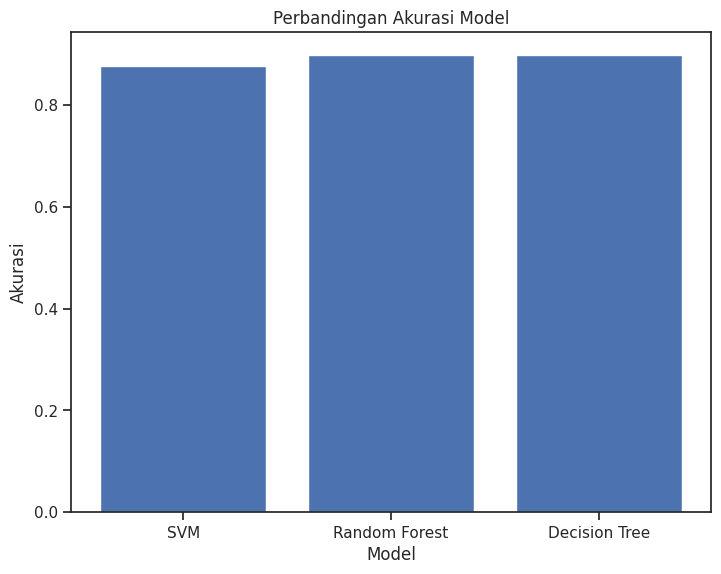

In [114]:
# Perbandingan akurasi pada model

fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
model = ['SVM', 'Random Forest', 'Decision Tree']
accuracy = [accuracy_svm, accuracy_rf, accuracy_dt]

ax.bar(model, accuracy)
plt.title('Perbandingan Akurasi Model')
plt.xlabel('Model')
plt.ylabel('Akurasi')
plt.show()

In [115]:
# print hasil akurasi dari masing-masing model dalam bentuk dataframe
df_accuracy = pd.DataFrame({'Model': [ 'SVM', 'Random Forest', 'Decision Tree'],
                             'Accuracy': [accuracy_svm, accuracy_rf, accuracy_dt]})
df_accuracy

,Model,Accuracy
0,SVM,0.876467
1,Random Forest,0.897988
2,Decision Tree,0.898547


## Testing Model

In [116]:
# Load model yang disimpan
model = load('model_rf.joblib')

# Load TF-IDF Vectorizer
vectorizer = load('correct_tfidf_vectorizer.joblib')

# Tetapkan input teks secara manual
test_input = "Get contact bagus sekali"

# Preprocess text using the existing function
test_input_preprocessed = preprocess_text(test_input)

# Tampilkan hasil preprocessing
print(f'Teks setelah preprocessing: {test_input_preprocessed}')

# Transformasi input teks yang telah dipreprocessed menjadi fitur menggunakan vectorizer yang benar
test_input_transformed = vectorizer.transform([test_input_preprocessed])

# Buat prediksi
prediksi = model.predict(test_input_transformed)

# Ambil hasil prediksi
hasil_prediksi = prediksi[0]

# Map hasil prediksi ke label sentimen menggunakan if-else
if hasil_prediksi == -1:
    sentimen = 'Negatif'
elif hasil_prediksi == 0:
    sentimen = 'Netral'
elif hasil_prediksi == 1:
    sentimen = 'Positif'
else:
    sentimen = 'Label tidak dikenali'

# Cetak hasil sentimen
print(f'Hasil prediksi: {sentimen}')

# Simpan hasil ke file
with open('hasil_prediksi.txt', 'w') as file:
    file.write(f'Teks asli: {test_input}\n')
    file.write(f'Teks setelah preprocessing: {test_input_preprocessed}\n')
    file.write(f'Hasil sentimen: {sentimen}\n')

Teks setelah preprocessing: get contact bagus sekali
Hasil prediksi: Positif


In [117]:
# Load model yang disimpan
model = load('model_rf.joblib')

# Load TF-IDF Vectorizer
vectorizer = load('correct_tfidf_vectorizer.joblib')

# Tetapkan input teks secara manual
test_input2 = "Get contact jelek harus premium dihhh"

# Preprocess text using the existing function
test_input_preprocessed2 = preprocess_text(test_input2)

# Tampilkan hasil preprocessing
print(f'Teks setelah preprocessing: {test_input_preprocessed2}')

# Transformasi input teks yang telah dipreprocessed menjadi fitur menggunakan vectorizer yang benar
test_input_transformed2 = vectorizer.transform([test_input_preprocessed2])

# Buat prediksi
prediksi = model.predict(test_input_transformed2)

# Ambil hasil prediksi
hasil_prediksi = prediksi[0]

# Map hasil prediksi ke label sentimen menggunakan if-else
if hasil_prediksi == -1:
    sentimen = 'Negatif'
elif hasil_prediksi == 0:
    sentimen = 'Netral'
elif hasil_prediksi == 1:
    sentimen = 'Positif'
else:
    sentimen = 'Label tidak dikenali'

# Cetak hasil sentimen
print(f'Hasil prediksi: {sentimen}')

# Simpan hasil ke file
with open('hasil_prediksi.txt', 'w') as file:
    file.write(f'Teks asli: {test_input2}\n')
    file.write(f'Teks setelah preprocessing: {test_input_preprocessed2}\n')
    file.write(f'Hasil sentimen: {sentimen}\n')

Teks setelah preprocessing: get contact jelek harus premium dihhh
Hasil prediksi: Negatif
